# Sales Prediction - Data Exploration & Preprocessing
*Note: Notebook được tạo dựa trên kế hoạch 3 bước (Load, Sanity Check, EDA)*

## Bước 0: Import Libraries
Khởi tạo các thư viện cần thiết cho việc xử lý dữ liệu và trực quan hóa.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## Bước 1: Load Data
Đọc tập dữ liệu `online_retail_II.xlsx`. (Có thể sẽ mất một chút thời gian vì dung lượng file khá lớn).

In [10]:
# Đọc dữ liệu từ cả hai sheet của file Excel (2009-2010 và 2010-2011)
print("Đang đọc dữ liệu... (sẽ mất khoảng 1-2 phút)")
df_dict = pd.read_excel('online_retail_II.xlsx', sheet_name=None)
df = pd.concat(df_dict.values(), ignore_index=True)
display(df.head())

Đang đọc dữ liệu... (sẽ mất khoảng 1-2 phút)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Bước 2: Sanity Check
### a. Kiểm tra kiểu dữ liệu & Giá trị thiếu (Missing Values)

In [11]:
# Kiểm tra kiểu dữ liệu (dtype)
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
# Thống kê lượng missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
display(pd.DataFrame({'Missing Count': missing_data, 'Missing %': missing_percent}))


--- Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

--- Missing Values ---


,Missing Count,Missing %
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


### b. Kiểm tra Phân phối & Outliers cơ bản
Nhận xét: Sẽ thấy `Quantity` có giá trị âm rất sâu (trả hàng) và `Price` có giá trị 0 hoặc âm.

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


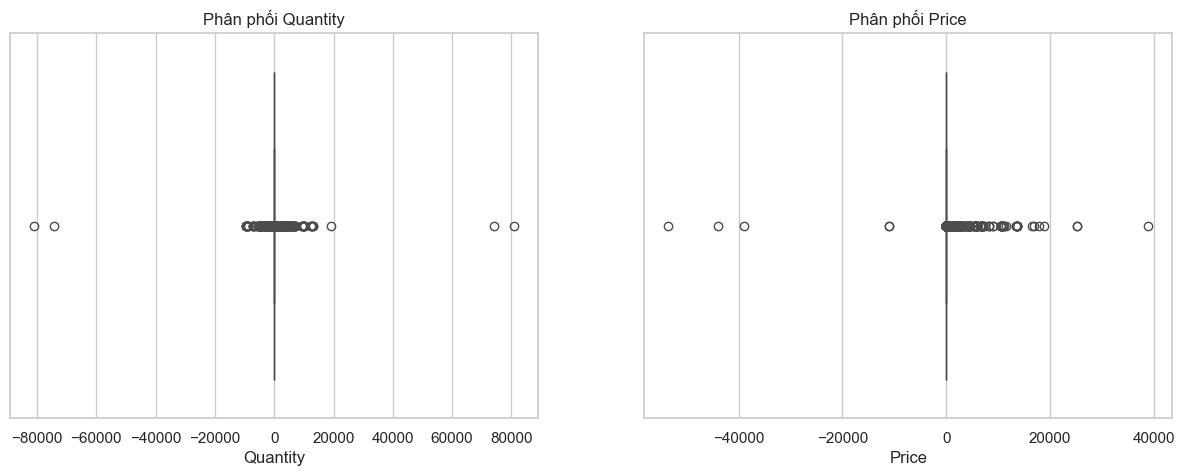

In [12]:
# Xem mô tả thống kê của các cột số
display(df.describe())

# Trực quan hóa Outliers bằng Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Quantity'], ax=axes[0]).set_title('Phân phối Quantity')
sns.boxplot(x=df['Price'], ax=axes[1]).set_title('Phân phối Price')
plt.show()


## Bước 3: Exploratory Data Analysis (EDA)
Khám phá các Insight đặc biệt từ dữ liệu.

### 3.1 Giao dịch theo Ngày trong tuần (Day of Week)
**Nhận xét:** Nhìn biểu đồ bạn sẽ thấy Thứ 7 gần như không có / hoặc hoàn toàn trống vắng các giao dịch.

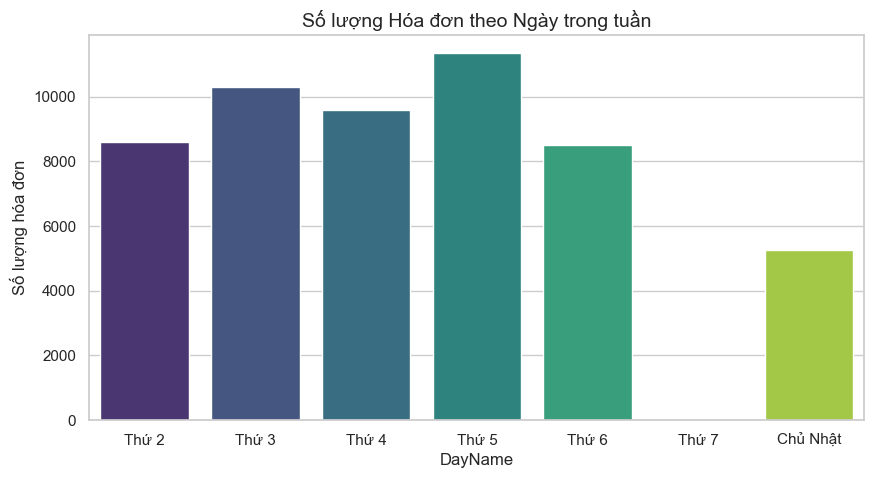

In [13]:
# Tạo thêm cột Thứ trong tuần (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# Mapping tên thứ cho dễ nhìn
day_names = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
df['DayName'] = df['DayOfWeek'].map(day_names)

# Đếm số lượng giao dịch (hóa đơn duy nhất) theo thứ
transactions_by_day = df.groupby('DayName')['Invoice'].nunique().reindex(day_names.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=transactions_by_day.index, y=transactions_by_day.values, palette='viridis')
plt.title('Số lượng Hóa đơn theo Ngày trong tuần', fontsize=14)
plt.ylabel('Số lượng hóa đơn')
plt.show()


### 3.2 Phân tích Đơn hàng Hủy / Hoàn trả
**Nhận xét:** Hóa đơn bắt đầu bằng 'C' và `Quantity < 0` là đặc trưng của các đơn bị trả/hủy.

In [14]:
# Tạo cột flag cho đơn bị hủy/trả
df['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')

# Tính tỷ lệ hủy
cancel_rate = df['Is_Cancelled'].mean() * 100
print(f"Tỷ lệ dòng dữ liệu là đơn hủy/trả hàng: {cancel_rate:.2f}%")

# Xem thử các đơn hàng bị trả về
display(df[df['Is_Cancelled']].head())


Tỷ lệ dòng dữ liệu là đơn hủy/trả hàng: 1.83%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,DayOfWeek,DayName,Is_Cancelled
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1,Thứ 3,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,1,Thứ 3,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,1,Thứ 3,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,1,Thứ 3,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1,Thứ 3,True


### 3.3 Tập trung Địa lý (Country)
**Nhận xét:** Một đặc trưng cực kỳ rõ nét của bộ dataset này là thị trường tập trung vào United Kingdom.

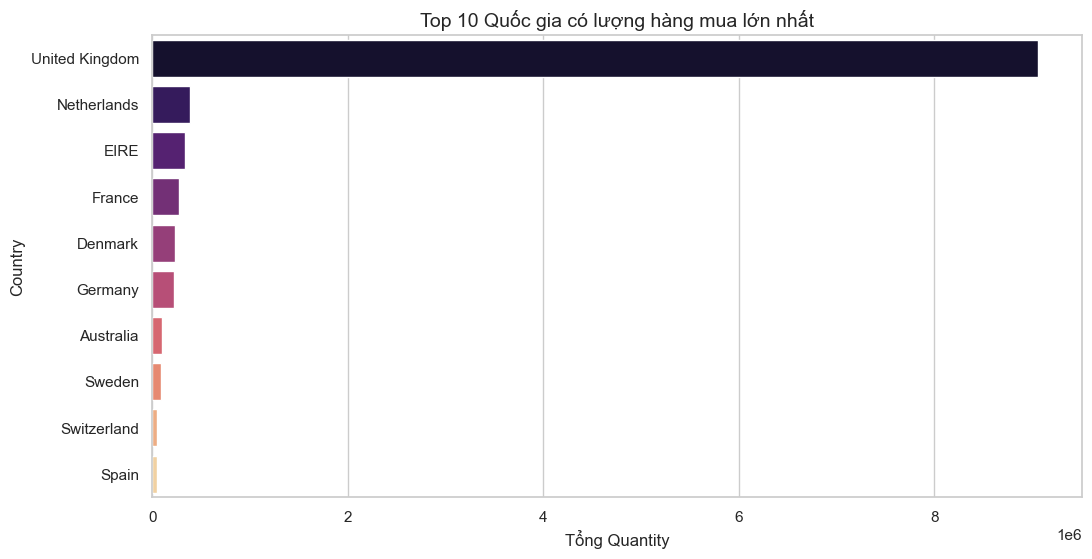

In [15]:
# Tính tổng số lượng hàng bán ra theo quốc gia (Bỏ qua đơn hủy)
country_sales = df[~df['Is_Cancelled']].groupby('Country')['Quantity'].sum().sort_values(ascending=False)

# Vẽ biểu đồ Top 10
plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.head(10).values, y=country_sales.head(10).index, palette='magma')
plt.title('Top 10 Quốc gia có lượng hàng mua lớn nhất', fontsize=14)
plt.xlabel('Tổng Quantity')
plt.show()


### 3.4 Xu hướng theo Thời gian (Seasonality)
**Nhận xét:** Doanh thu tăng vọt ở quý 4 hằng năm (hiệu ứng mùa lễ hội cuối năm).

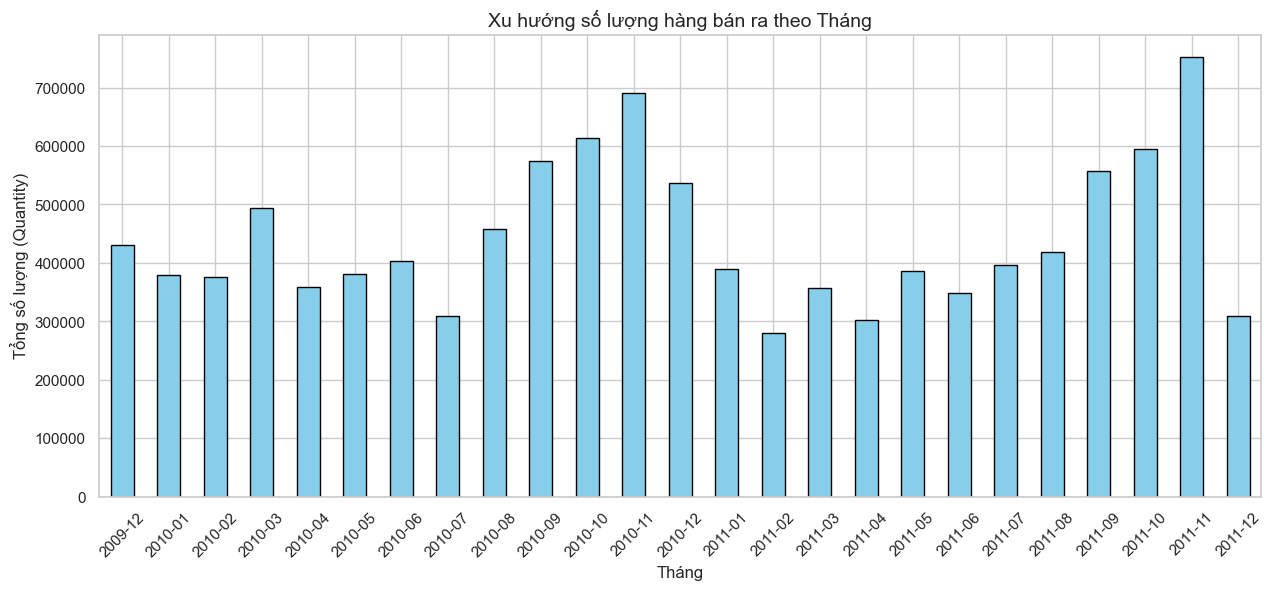

In [16]:
# Gom nhóm theo Tháng
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Lấy xu hướng Quantity bán ra theo thời gian
sales_trend = df[~df['Is_Cancelled']].groupby('YearMonth')['Quantity'].sum()

plt.figure(figsize=(15, 6))
sales_trend.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Xu hướng số lượng hàng bán ra theo Tháng', fontsize=14)
plt.xlabel('Tháng')
plt.ylabel('Tổng số lượng (Quantity)')
plt.xticks(rotation=45)
plt.show()
